In [6]:
%matplotlib inline

import time
from collections.abc import Callable, Iterator

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from d2l import torch as d2l

In [7]:
# Airfoil Dataset Loader

d2l.DATA_HUB["airfoil"] = (
    d2l.DATA_URL
    + "airfoil_self_noise.dat",
    "76e5be1548fd8222e5074cf0faae75edff8cf93f",
)


def get_airfoil_data(
    batch_size: int = 10,
    num_examples: int = 1500,
) -> tuple[
    DataLoader,
    int,
]:
    file_path = d2l.download(
        "airfoil",
        folder="../data",
    )

    raw_data = np.genfromtxt(
        file_path,
        dtype=np.float32,
        delimiter="\t",
    )

    standardized_data = (
        raw_data
        - raw_data.mean(
            axis=0,
        )
    ) / raw_data.std(
        axis=0,
    )

    data = torch.from_numpy(
        standardized_data
    )

    features = data[
        :num_examples,
        :-1,
    ]

    targets = data[
        :num_examples,
        -1,
    ]

    data_loader: DataLoader = (
        d2l.load_array(
            (
                features,
                targets,
            ),
            batch_size,
            is_train=True,
        )
    )

    return (
        data_loader,
        features.shape[1],
    )

In [8]:
# Concise Training Function

OptimizerFactory = Callable[
    [Iterator[nn.Parameter]],
    torch.optim.Optimizer,
]

ConciseTrainingResult = tuple[
    nn.Module,
    list[float],
    list[float],
]

def train_concise(
    optimizer_factory: OptimizerFactory,
    data_loader: DataLoader,
    num_features: int,
    num_epochs: int = 4,
) -> ConciseTrainingResult:
    
    # model 설정
    model = nn.Sequential(
        nn.Linear(
            in_features=num_features,
            out_features=1,
        )
    )
    
    def initialize_weights(
        module: nn.Module,
    ) -> None:
        if isinstance(
            module,
            nn.Linear,
        ): 
            nn.init.normal_(
                module.weight,
                std=1e-2
            )

            if module.bias is not None:
                nn.init.zeros_(
                    module.bias
                )
                
                
    model.apply(
        initialize_weights
    )
    
    optimizer = optimizer_factory(
        model.parameters()
    )
    
    loss_function = nn.MSELoss(
        reduction="none"
    )
    
    elapsed_training_time = 0.0
    evaluation_times: list[float] = []
    evaluation_losses: list[float] = []

    examples_since_evaluation = 0
    
    
    for _ in range(num_epochs):
        for X, targets in data_loader:
            start_time = time.perf_counter()
            
            optimizer.zero_grad()
            
            predictions = model(X)
            
            targets = targets.reshape(
                predictions.shape
            )
            
            losses = loss_function(
                predictions,
                targets,
            )
            
            losses.mean().backward()
            
            optimizer.step()
            
            elapsed_training_time += (
                time.perf_counter()
                - start_time
            )

            examples_since_evaluation += (
                X.shape[0]
            )

            if examples_since_evaluation >= 200:
                evaluation_times.append(
                    elapsed_training_time
                )

                # MSELoss에는 1/2 factor가 없으므로
                # scratch squared_loss와 비교하기 위해 2로 나눔
                evaluation_loss = (
                    d2l.evaluate_loss(
                        model,
                        data_loader,
                        loss_function,
                    )
                    / 2
                )

                evaluation_losses.append(
                    evaluation_loss
                )

                examples_since_evaluation = 0

    print(
        f"loss: "
        f"{evaluation_losses[-1]:.3f}, "
        f"{elapsed_training_time / num_epochs:.3f} "
        f"sec/epoch"
    )

    return (
        model,
        evaluation_times,
        evaluation_losses,
    )

In [9]:
# torch.optim.SGD Training

airfoil_loader, num_features = (
    get_airfoil_data(
        batch_size=10,
    )
)


def create_sgd_optimizer(
    parameters: Iterator[nn.Parameter],
) -> torch.optim.Optimizer:
    return torch.optim.SGD(
        parameters,
        lr=0.01,
    )


(
    concise_model,
    concise_times,
    concise_losses,
) = train_concise(
    optimizer_factory=create_sgd_optimizer,
    data_loader=airfoil_loader,
    num_features=num_features,
    num_epochs=4,
)

loss: 0.243, 0.044 sec/epoch


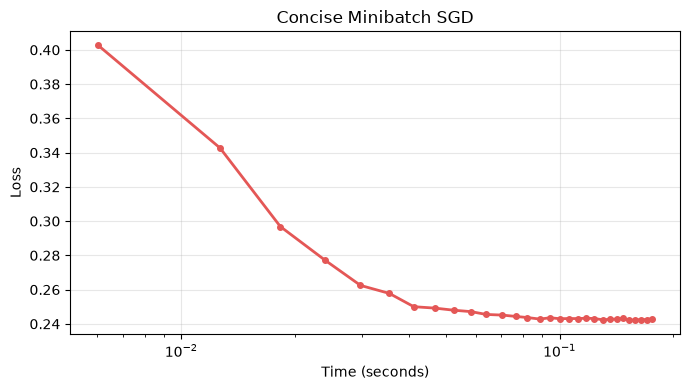

In [10]:
# Loss Curve

figure, axis = d2l.plt.subplots(
    figsize=(
        7,
        4,
    )
)

axis.plot(
    concise_times,
    concise_losses,
    color="#E45756",
    linewidth=2,
    marker="o",
    markersize=4,
)

axis.set_xscale(
    "log"
)

axis.set_xlabel(
    "Time (seconds)"
)

axis.set_ylabel(
    "Loss"
)

axis.set_title(
    "Concise Minibatch SGD"
)

axis.grid(
    alpha=0.3,
)

figure.tight_layout()

d2l.plt.show()